# Noiseless_integrable_Traceout

In [125]:
import sys
sys.path.insert(0, '../../../src/')

import numpy as np
import qiskit as qk
import matplotlib.pyplot as plt
import multiprocessing as mp
import tensorflow as tf
import random
import pickle as pkl

from src import *
from qiskit.quantum_info import Operator

from kraus_channels import isomery_to_kraus
from spectrum import Spectrum, channel_spectrum, complex_spacing_ratio, coat_spectrum

#np.set_printoptions(threshold=sys.maxsize)
np.set_printoptions(precision=1)

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"




## No coupling

In [2]:
n = 4        # number of qubits that are measured
n_anc = 0    # number of ancilla qubits, that are trace out/discarded/not measured
L = 5      # layers of circuit
reps = 10    # repeated experiments/ different target circuits

circuit_list = []

# same experiment repeated 10 times with different seeds
for i in range(reps):
    np.random.seed(42 + i) # different seeds for each realization
    circuit_target = integrable_circuit(n + n_anc, L)
    
    circuit_SPAM_list = prepare_SPAM_strings(n, n_anc)
    
    config_list, circuit_map_list = generate_circuit_sandwich(n = n, 
                                                                n_anc = n_anc,
                                                                circuit_target = circuit_target, 
                                                                N = 5000 - 6**n)
    

    # 5000 circuit per target circuit, 1296 for spam and 3704 for tomography
    # ten different realizations of target circuits, ing in total 50000 circuits
    # please run with shots = 1024, no compiling optimization if possible
    circuit_list.extend(circuit_SPAM_list)
    circuit_list.extend(circuit_map_list)

In [4]:
print(circuit_map_list[0])

                      ░  ┌────────────┐ ┌──────────────────┐┌─────────────┐ »
     q_0: ────────────░──┤ Rz(1.1042) ├─┤0                 ├┤ Rz(-1.3558) ├─»
           ┌───────┐  ░ ┌┴────────────┤ │  (XX+YY)(-π/2,0) │└┬────────────┤ »
     q_1: ─┤ Rx(π) ├──░─┤ Rz(-2.8607) ├─┤1                 ├─┤ Rz(2.8233) ├─»
           ├───────┤  ░ ├─────────────┴┐├──────────────────┤┌┴────────────┤ »
     q_2: ─┤ Rx(π) ├──░─┤ Rz(-0.98455) ├┤0                 ├┤ Rz(-2.1509) ├─»
          ┌┴───────┴┐ ░ └┬────────────┬┘│  (XX+YY)(-π/2,0) │├─────────────┴┐»
     q_3: ┤ Ry(π/2) ├─░──┤ Rz(0.9049) ├─┤1                 ├┤ Rz(-0.70389) ├»
          └─────────┘ ░  └────────────┘ └──────────────────┘└──────────────┘»
c46296: 4/══════════════════════════════════════════════════════════════════»
                                                                            »
«            ┌─────────────┐                    ┌──────────────────┐»
«     q_0: ──┤ Rz(0.56545) ├────────────────────┤0                 ├»
« 

## Tuned

In [7]:
n = 4        # number of qubits that are measured
n_anc = 1    # number of ancilla qubits, that are trace out/discarded/not measured
L = 5      # layers of circuit
reps = 10    # repeated experiments/ different target circuits

circuit_list = []

# same experiment repeated 10 times with different seeds
for i in range(reps):
    np.random.seed(42 + i) # different seeds for each realization
    circuit_target = integrable_circuit_tuned(n + n_anc, L)
    
    circuit_SPAM_list = prepare_SPAM_strings(n, n_anc)
    
    config_list, circuit_map_list = generate_circuit_sandwich(n = n, 
                                                                n_anc = n_anc,
                                                                circuit_target = circuit_target, 
                                                                N = 5000 - 6**n)
    

    # 5000 circuit per target circuit, 1296 for spam and 3704 for tomography
    # ten different realizations of target circuits, ing in total 50000 circuits
    # please run with shots = 1024, no compiling optimization if possible
    circuit_list.extend(circuit_SPAM_list)
    circuit_list.extend(circuit_map_list)

In [8]:
print(circuit_map_list[0])

           ┌──────────┐ ░  ┌────────────┐ ┌──────────────────┐ ┌────────────┐ »
      q_0: ┤ Ry(-π/2) ├─░──┤ Rz(1.1042) ├─┤0                 ├─┤ Rz(2.8233) ├─»
           ├──────────┤ ░ ┌┴────────────┤ │  (XX+YY)(-π/2,0) │┌┴────────────┤ »
      q_1: ┤ Ry(-π/2) ├─░─┤ Rz(-2.8607) ├─┤1                 ├┤ Rz(-2.1509) ├─»
           └──────────┘ ░ ├─────────────┴┐├──────────────────┤├─────────────┴┐»
      q_2: ─────────────░─┤ Rz(-0.98455) ├┤0                 ├┤ Rz(-0.70389) ├»
           ┌──────────┐ ░ └┬────────────┬┘│  (XX+YY)(-π/2,0) │├─────────────┬┘»
      q_3: ┤ Rx(-π/2) ├─░──┤ Rz(0.9049) ├─┤1                 ├┤ Rz(0.56545) ├─»
           └──────────┘ ░ ┌┴────────────┤ └┬───────────────┬─┘└─────────────┘ »
      q_4: ─────────────░─┤ Rz(-1.3558) ├──┤ Rz(-0.076681) ├──────────────────»
                        ░ └─────────────┘  └───────────────┘                  »
c146296: 4/═══════════════════════════════════════════════════════════════════»
                                        

# Inspect spectrum

In [130]:
def integrable_circuit_tuned(n, L, couple):
    theta_list = [np.random.uniform(-np.pi, np.pi, n) for i in range(L)]
    sqrt_iSWAP = iSwapGate().power(1 / 2)
    tuned_coup = iSwapGate().power(couple)

    circuit = qk.QuantumCircuit(n)
    for i, theta in enumerate(theta_list):

        offset = i%2
        for j in range(n):
            circuit.rz(theta[j], j)

        for j in range((n - offset) // 2):
            if j + offset != 2:  # tune the coupling in the middle of the chain
                circuit.append(sqrt_iSWAP, [2 * j + offset, 2 * j + 1 + offset])
            else:
                circuit.append(tuned_coup, [2 * j + offset, 2 * j + 1 + offset])
            

    return circuit

In [399]:
from kraus_channels import KrausMap
from quantum_channel import DilutedChannel

csr_list = []
for i in range(10):
    np.random.seed(42 + i) # different seeds for each realization|
    circuit_target = integrable_circuit_tuned(5, 20, 1/8)
    U = Operator(circuit_target).data

    kraus_map = isomery_to_kraus(U, 2)
    #kraus_chaos = KrausMap(2**4, rank=10)
    #kraus_map = DilutedChannel(kraus_map, kraus_chaos, 0.1)

    spectrum = channel_spectrum(kraus_map)
    csr = complex_spacing_ratio(spectrum)
    csr_list.append(csr)

    #spectrum.plot_circle()
    #spectrum.plot()

    #plt.show()

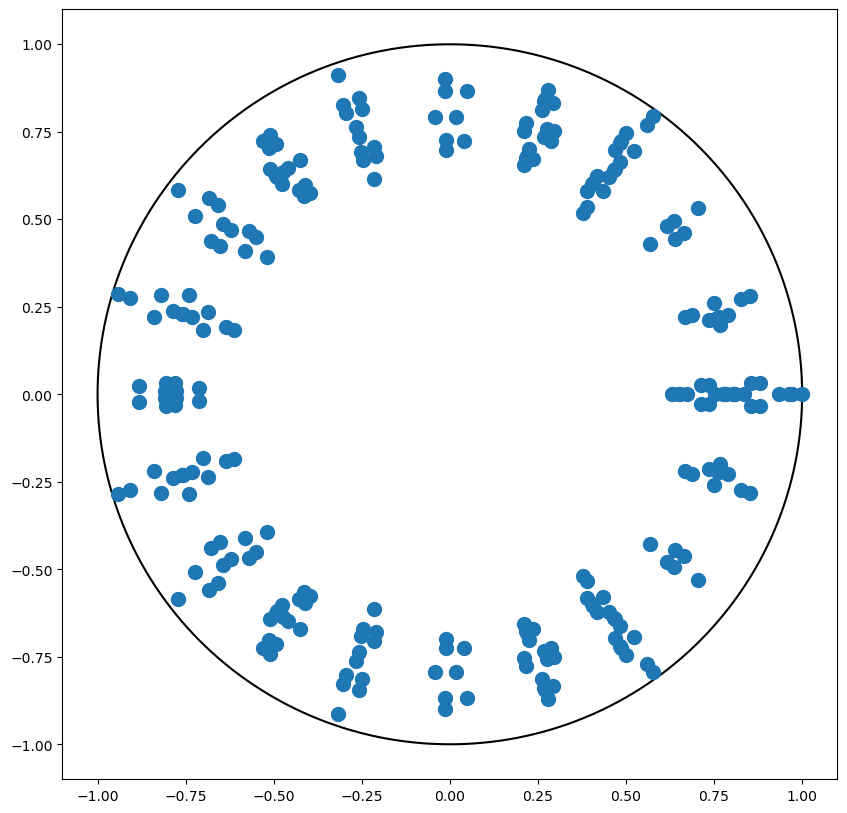

In [402]:
spectrum.plot_circle()
spectrum.plot()

plt.show()

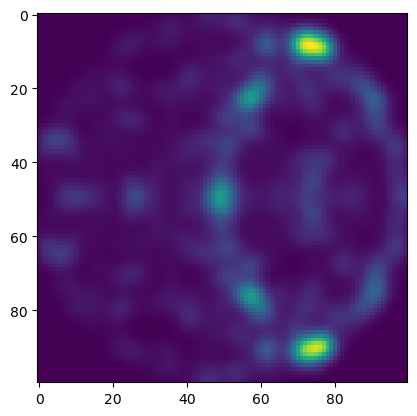

In [393]:
csr = Spectrum(csr_list)
csr_coat = coat_spectrum(csr, sigma=0.05)
plt.imshow(csr_coat)

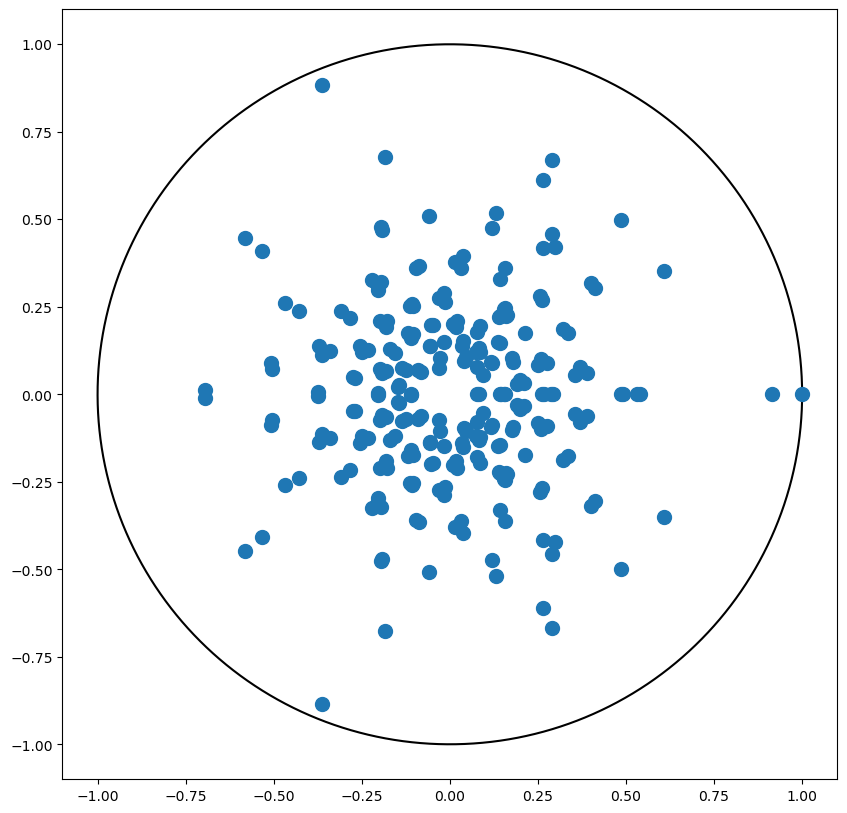

In [422]:
circuit_target = integrable_circuit_tuned(5, 50, 1/8)
U = Operator(circuit_target).data

kraus_map = isomery_to_kraus(U, 2)
#kraus_chaos = KrausMap(2**4, rank=10)
#kraus_map = DilutedChannel(kraus_map, kraus_chaos, 0.1)

spectrum = channel_spectrum(kraus_map)
spectrum.plot_circle()
spectrum.plot()

plt.show()